Extra Practical - 7th

Name:Vedanti Ramde Roll No:CS23153

AIM:-To apply Support Vector Machine for Regression on Students Performance Dataset and analyze the impact of different kernels on model accuracy.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ml_dataset/Student_Performance_dataset_5000.csv")

df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [ ]:
df.columns

Index(['student_id', 'age', 'gender', 'academic_level', 'study_hours',
       'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'internet_quality', 'mental_health_score', 'focus_index',
       'burnout_level', 'productivity_score', 'exam_score'],
      dtype='object')

In [ ]:
for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])

In [ ]:
df = df.drop("student_id", axis=1)

In [ ]:
categorical_cols = ['gender', 'academic_level', 'part_time_job', 'internet_quality']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop("exam_score", axis=1)
y = df["exam_score"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train, y_train)

y_pred_linear = svr_linear.predict(X_test)

print("🔹 Linear Kernel Results")
print("MAE:", mean_absolute_error(y_test, y_pred_linear))
print("MSE:", mean_squared_error(y_test, y_pred_linear))
print("R2 Score:", r2_score(y_test, y_pred_linear))

🔹 Linear Kernel Results
MAE: 3.9678466330327127
MSE: 25.0744218107911
R2 Score: 0.8159810658121096


In [ ]:
svr_rbf = SVR(kernel='rbf')
svr_rbf.fit(X_train, y_train)

y_pred_rbf = svr_rbf.predict(X_test)

print("\n🔹 RBF Kernel Results")
print("MAE:", mean_absolute_error(y_test, y_pred_rbf))
print("MSE:", mean_squared_error(y_test, y_pred_rbf))
print("R2 Score:", r2_score(y_test, y_pred_rbf))


🔹 RBF Kernel Results
MAE: 4.189278492255337
MSE: 28.21003292928237
R2 Score: 0.7929690968659647


In [ ]:
svr_poly = SVR(kernel='poly', degree=3)
svr_poly.fit(X_train, y_train)

y_pred_poly = svr_poly.predict(X_test)

print("\n🔹 Polynomial Kernel Results")
print("MAE:", mean_absolute_error(y_test, y_pred_poly))
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("R2 Score:", r2_score(y_test, y_pred_poly))


🔹 Polynomial Kernel Results
MAE: 4.785656958278709
MSE: 35.977146806881194
R2 Score: 0.7359669443036037


In [ ]:
results = pd.DataFrame({
    "Kernel": ["Linear", "RBF", "Polynomial"],
    "R2 Score": [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_rbf),
        r2_score(y_test, y_pred_poly)
    ]
})

results

,Kernel,R2 Score
0,Linear,0.815981
1,RBF,0.792969
2,Polynomial,0.735967


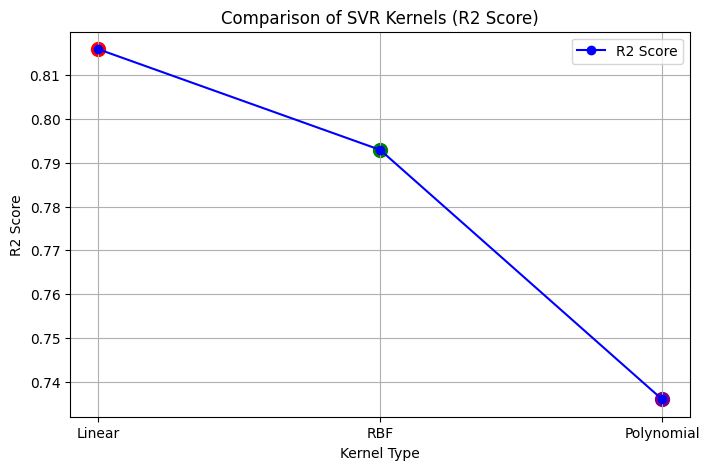

In [ ]:
# Store R2 scores
kernels = ["Linear", "RBF", "Polynomial"]
r2_scores = [
    r2_score(y_test, y_pred_linear),
    r2_score(y_test, y_pred_rbf),
    r2_score(y_test, y_pred_poly)
]

# Create line graph
plt.figure(figsize=(8,5))

plt.plot(kernels, r2_scores, marker='o', color='blue', label='R2 Score')

# Add individual colored markers
plt.scatter("Linear", r2_scores[0], color='red', s=100)
plt.scatter("RBF", r2_scores[1], color='green', s=100)
plt.scatter("Polynomial", r2_scores[2], color='purple', s=100)

plt.title("Comparison of SVR Kernels (R2 Score)")
plt.xlabel("Kernel Type")
plt.ylabel("R2 Score")
plt.grid(True)
plt.legend()

plt.show()